In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter

In [111]:
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

In [112]:
# case_1 {'tau': 0.05, 'sigma': 2.0}
# case_2 {'tau': 0.05, 'sigma': 1.4142135623730951}
# case_3 {'tau': 0.05, 'sigma': 1.0}
# case_4 {'tau': 0.5, 'sigma': 2.0}
# case_5 {'tau': 0.5, 'sigma': 1.4142135623730951}
# case_6 {'tau': 0.5, 'sigma': 1.0}
# case_7 {'tau': 2.0, 'sigma': 2.0}
# case_8 {'tau': 2.0, 'sigma': 1.4142135623730951}
# case_9 {'tau': 2.0, 'sigma': 1.0}

In [113]:
# ==========================================================
# READ FILE
# ==========================================================
file_name = "ensemble_case_9.csv"
df = pd.read_csv(file_name)

In [114]:
t = df["time"]
x = df["mean_x"]
v = df["mean_v"]
# x = np.sqrt(df["var_x"]   + df["mean_x"]**2) #rms
# v = np.sqrt(df["var_v"]   + df["mean_v"]**2) #rms
a = df["mean_a"]
f_noise = df["mean_eta"]
f_spring = df["mean_f_spring"]
f_damp = df["mean_f_damp"]
f_total = df["mean_f_total"]
ke = df["mean_ke"]
pe = df["mean_pe"]
te = df["mean_te"]

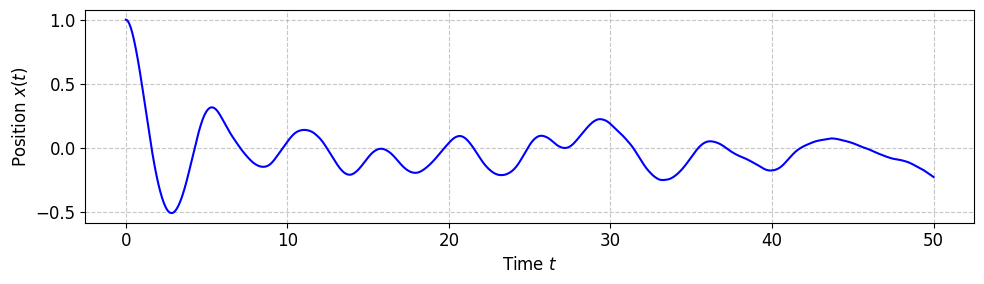

In [115]:
# ==========================================================
# PLOT DISPLACEMENT vs TIME
# ==========================================================
plt.figure(figsize=(10,3))
plt.plot(t, x, lw=1.5, color='b')
# plt.ylim([-1.1, 1.1])
plt.xlabel(r"Time $t$")
plt.ylabel(r"Position $x(t)$")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("position.png", dpi=600, bbox_inches="tight")
plt.show()

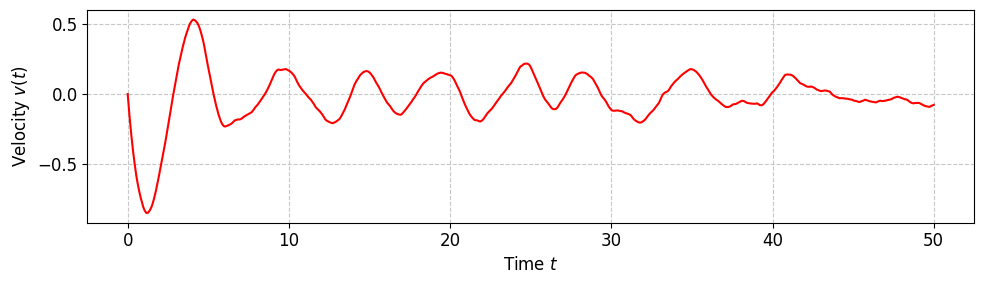

In [116]:
# ==========================================================
# PLOT VELOCITY vs TIME
# ==========================================================
plt.figure(figsize=(10,3))
plt.plot(t, v, lw=1.5, color='r')
# plt.ylim([-2.1, 2.1])
plt.xlabel(r"Time $t$")
plt.ylabel(r"Velocity $v(t)$")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("velocity.png", dpi=600, bbox_inches="tight")
plt.show()

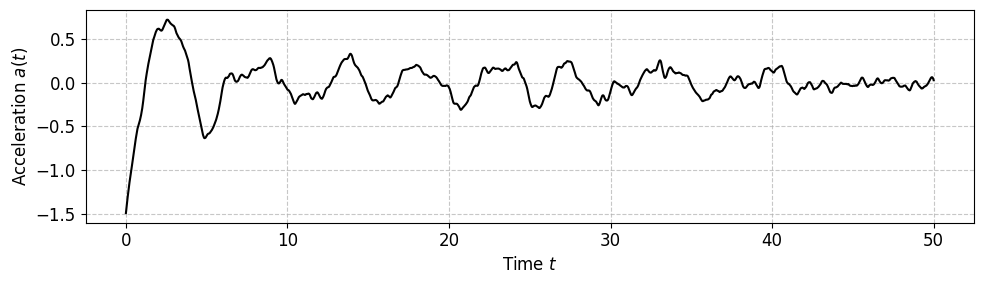

In [117]:
# ==========================================================
# PLOT ACCELERATION vs TIME
# ==========================================================
a_smooth = savgol_filter(a, 501, 3)
plt.figure(figsize=(10,3))
plt.plot(t, a_smooth, lw=1.5, color='k')
# plt.plot(t, a, lw=1, alpha=0.5)
# plt.ylim([-5.1, 5.1])
plt.xlabel(r"Time $t$")
plt.ylabel(r"Acceleration $a(t)$")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("accn.png", dpi=600, bbox_inches="tight")
plt.show()

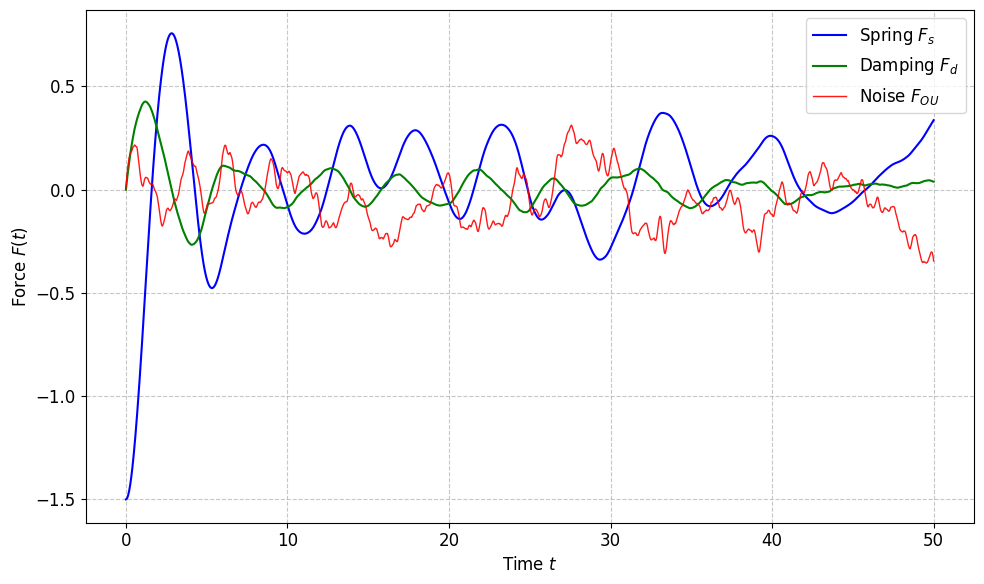

In [118]:
# ==========================================================
# PLOT FORCE vs TIME
# ==========================================================
# f_noise_smooth = gaussian_filter1d(f_noise, sigma=10)
f_noise_smooth = savgol_filter(f_noise, 501, 3)
plt.figure()
plt.plot(t, f_spring, color='b', label='Spring $F_s$')
plt.plot(t, f_damp, color='g', label='Damping $F_d$')
plt.plot(t, f_noise_smooth, lw=1.0, color='r', alpha = 0.9, label='Noise $F_{OU}$')
# plt.plot(t, f_damp+f_spring+f_noise_smooth, color='k', label='Total $F=F_s+F_d+F_{OU}$')
# plt.plot(t, f_noise, lw=0.5, color='k', alpha=0.5)
# plt.ylim([-5.1, 5.1])
plt.xlabel(r"Time $t$")
plt.ylabel(r"Force $F(t)$")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("force.png", dpi=600, bbox_inches="tight")
plt.show()

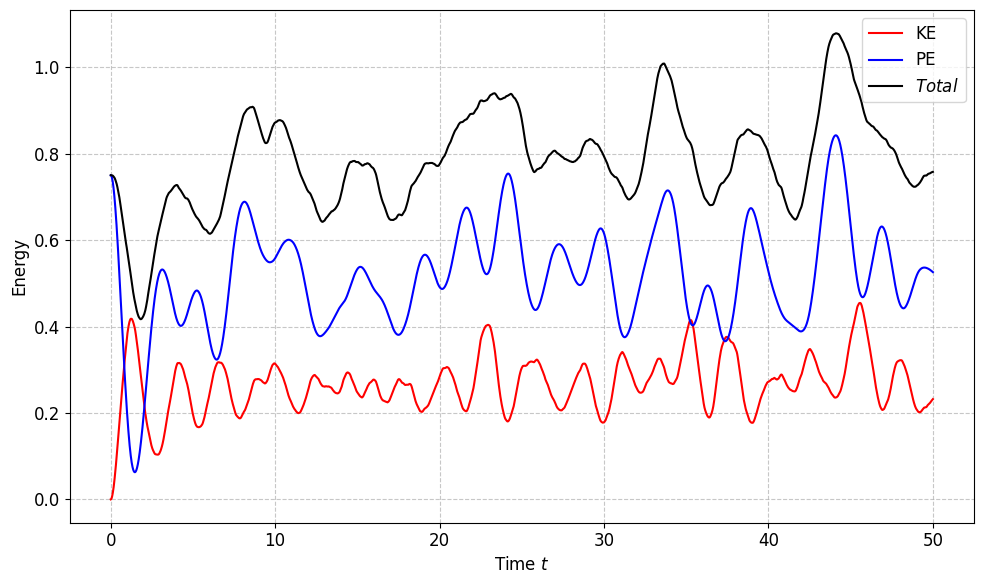

In [119]:
# ==========================================================
# PLOT ENERGY vs TIME
# ==========================================================
plt.figure()
plt.plot(t, ke, color='r', label='KE')
plt.plot(t, pe, color='b', label='PE')
plt.plot(t, te, color='k', label='$Total$')
# plt.ylim([-5.1, 5.1])
plt.xlabel(r"Time $t$")
plt.ylabel(r"Energy")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("energy.png", dpi=600, bbox_inches="tight")
plt.show()

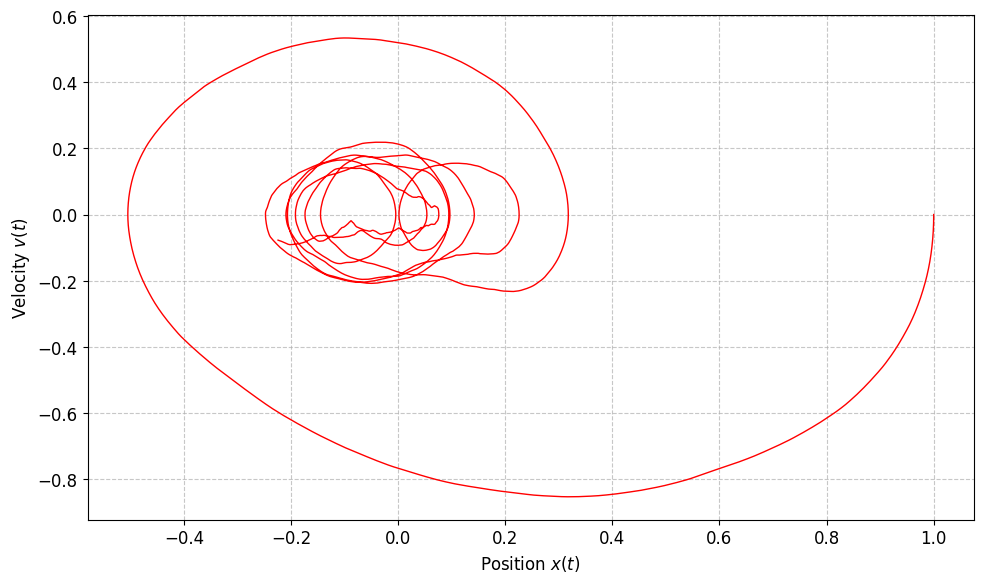

In [120]:
# ==========================================================
# PLOT PHASE SPACE
# ==========================================================
plt.figure()
plt.plot(x, v, lw=1, color='r')
# plt.ylim([-5.1, 5.1])
plt.ylabel(r"Velocity $v(t)$")
plt.xlabel(r"Position $x(t)$")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("phase.png", dpi=600, bbox_inches="tight")
plt.show()

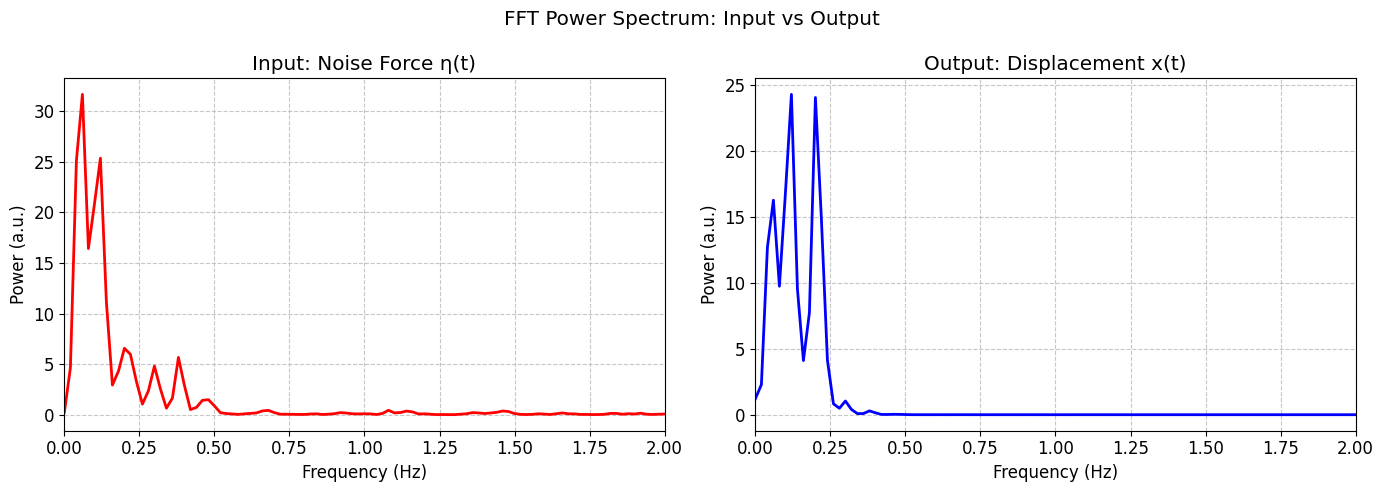

In [121]:
# =====================================================
# POWER SPECTRAL DENSITY (PSD)
# =====================================================
dt = t[1] - t[0]
N  = len(t)
eta = f_noise
# REMOVE MEAN
x_n   = x - np.mean(x)
eta_n = eta - np.mean(eta)

# WINDOWING
window = np.hanning(N)
xw   = x_n * window
etaw = eta_n * window

# FFT
freq = np.fft.rfftfreq(N, d=dt)
Xf   = np.fft.rfft(xw)
Ef   = np.fft.rfft(etaw)

PSDx = (np.abs(Xf)**2) / N
PSDe = (np.abs(Ef)**2) / N

# smooth for readability
PSDx_smooth = gaussian_filter1d(PSDx, sigma=0.5)
PSDe_smooth = gaussian_filter1d(PSDe, sigma=0.5)
# PSDx_smooth = savgol_filter(PSDx, 15, 11)
# PSDe_smooth = savgol_filter(PSDe, 15, 11)

# THEORETICAL DAMPED RESONANCE
# m, k, c = 1.0, 5.0, 0.5
# omega0 = np.sqrt(k/m)
# gamma = c/(2*m)

# if omega0 > gamma:
#     omega_d = np.sqrt(omega0**2 - gamma**2)
#     f_res = omega_d / (2*np.pi)
# else:
#     f_res = None

# PLOT INPUT
fig, ax = plt.subplots(1, 2, figsize=(14,5), sharex=True)
# plt.plot(freq, PSDe, alpha=0.30, lw=1)
ax[0].plot(freq, PSDe_smooth, lw=2, color='r')
# if f_res is not None:
#     ax[0].axvline(f_res, ls="--", lw=2, label=f"Resonance = {f_res:.3f} Hz")
ax[0].set_title("Input: Noise Force η(t)")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Power (a.u.)")
ax[0].set_xlim(0, 2)
# ax[0].set_ylim(0)
# ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.7)

# PLOT OUTPUT
# plt.plot(freq, PSDx, alpha=0.30, lw=1)
ax[1].plot(freq, PSDx_smooth, lw=2, color='b')
# if f_res is not None:
#     ax[1].axvline(f_res, ls="--", lw=2, label=f"Resonance = {f_res:.3f} Hz")
ax[1].set_title("Output: Displacement x(t)")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Power (a.u.)")
ax[1].set_xlim(0, 2)
# ax[1].set_ylim(0)
# ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("FFT Power Spectrum: Input vs Output")
plt.tight_layout()
plt.savefig("fft.png", dpi=600, bbox_inches="tight")
plt.show()

# print(f"Natural angular frequency ω0 = {omega0:.3f}")
# print(f"Damping factor γ =", gamma)
# if f_res is not None:
#     print(f"Damped resonance frequency = {f_res:.3f} Hz")

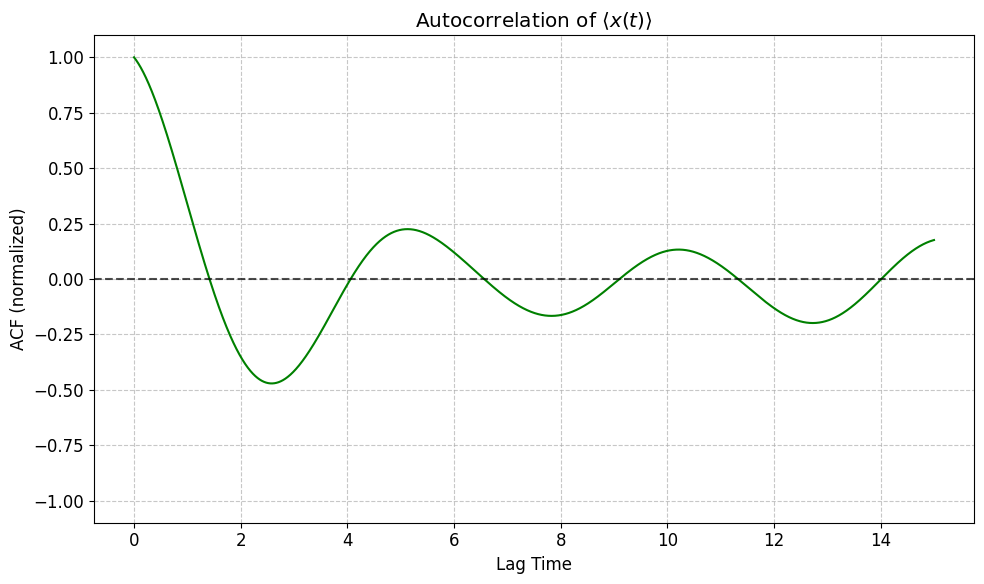

In [122]:
# ==========================================
# Autocorrelation
# ==========================================
dt = t[1] - t[0]
N = len(x)

# Remove mean before autocorrelation
x_fluc = x - np.mean(x)

# Autocorrelation
acf_full = np.correlate(x_fluc, x_fluc, mode='full')
acf = acf_full[N-1:]              # keep positive lags only

# Normalize
acf = acf / acf[0]

# Lag time axis
lag = np.arange(len(acf)) * dt

# Plot only first part for clarity
max_lag = int(0.3 * N)   # first 30%

plt.figure()
plt.plot(lag[:max_lag], acf[:max_lag], color='g')
plt.axhline(0, color='k', ls='--', alpha=0.7)
plt.xlabel("Lag Time")
plt.ylabel("ACF (normalized)")
plt.ylim(-1.1,1.1)
plt.title(r"Autocorrelation of $\left<x(t)\right>$")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("acf.png", dpi=600, bbox_inches="tight")
plt.show()